In [1]:
import numpy as np
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob
import emcee
import dust
import progressbar
import sys
import astropy.units as u
import astropy.constants as const
import traceback

In [ ]:
%reload_ext autoreload
%autoreload 2

from mcmc import *

test_phot = {'mag': np.array([22.0, 22.5]),
             'magerr': np.array([0.04, 0.05]),
             'inst_filt': np.array(['JWST_NIRCAM_F115W', 'JWST_NIRCAM_F200W'])}
mc = mcmc(model_type='rsg')
mc.run_emcee(test_phot)

### RSG grid

In [2]:
import glob
import os
import pickle
import synphot 
import numpy as np
from astropy.io import fits, ascii
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from astropy.io.misc.hdf5 import read_table_hdf5

In [2]:
comp = 'sil'
bandpass_dir = os.environ['BANDPASS']
nrc_filts = ['F070W','F090W','F115W','F140M','F150W','F162M',
                    'F164N','F150W2','F182M','F187N','F200W','F210M',
                    'F212N','F250M','F277W','F300M','F322W2','F323N',
                    'F335M','F356W','F360M','F405N','F410M','F430M',
                    'F444W','F460M','F466N','F470N','F480M']

In [3]:
temps = np.array([2600.0, 2800.0, 3000.0, 3200.0, 3400.0, 3600.0, 3800.0, 4000.0, 4200.0, 4500.0, 4800.0, 5000.0])
dust_temps = np.array([500.0, 800.0, 1000.0, 1200.0, 1500.0])
taus = np.array([0.01, 0.325, 0.641, 0.956, 1.27, 1.59, 1.9, 2.22, 2.53, 2.85, 3.16, 3.48, 3.79,
                 4.11, 4.42, 4.74, 5.05, 5.37, 5.68, 6.0])
lums = np.logspace(3, 6, 16)
rv = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
av = np.arange(0.0, 5.5, 0.5)
len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)

(12, 5, 20, 16, 6, 11)

In [5]:
full_grid = np.zeros((1497, len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
mags = {}
for flt in nrc_filts:
    mags[flt] = np.zeros((len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
len(full_grid.flatten())/1e6

1896.9984

In [6]:
spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_2600.0_500.0/rsg_2600.0_500.0.hdf5')
# spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_3000.0_800.0/rsg_3000.0_800.0.hdf5')

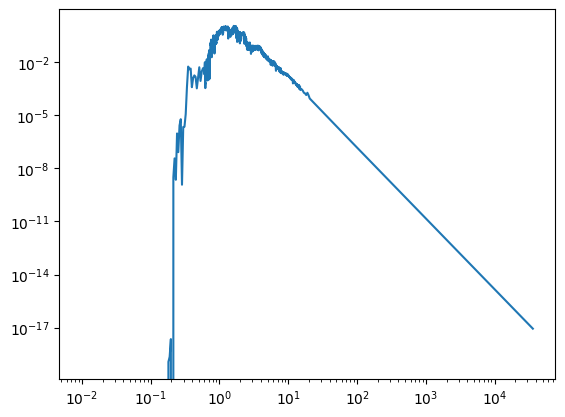

In [7]:
plt.plot(spec['lambda'], spec['flam_0.01'])
# plt.axvline(10)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(1e-4, 1e-1)
# plt.xlim(5, 15)

In [8]:
def get_jwst_filters(filtnam):

    inst, filt = filtnam.split(',')
    filt = filt.lower()
    inst = inst.lower()

    bpfile = os.path.join(bandpass_dir, inst, f'{filt.lower()}.txt')

    table = ascii.read(bpfile)
    wave = table['Microns']*1e4 * u.Angstrom
    trans = table['Throughput']

    bp = SpectralElement(Empirical1D, points=wave, lookup_table=trans)    
        
    return bp

In [9]:
def extinction_law(wave, Av, Rv, deredden=False):

    # Inverse wavelength dependent quantities
    x=1./(wave*1.0e-4)
    y=x-1.82

    # Variables proportional to extinction
    a=np.zeros(len(wave))
    b=np.zeros(len(wave))
    Fa=np.zeros(len(wave))
    Fb=np.zeros(len(wave))

    # Masks to apply piecewise Cardelli et al. function
    mask1 = np.where(x < 1.1)
    mask2 = np.where((x > 1.1) & (x < 3.3))
    mask3 = np.where(x > 3.3)
    mask4 = np.where(x > 5.9)

    x=1./(wave[mask1]*1.0e-4)
    y=x-1.82

    a[mask1]=0.574 * x**1.61
    b[mask1]=-0.527 * x**1.61

    x=1./(wave[mask2]*1.0e-4)
    y=x-1.82

    a[mask2]=1 + 0.17699 * y - 0.50447 * y**2 - 0.02427 * y**3 +\
        0.72085 * y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask2]=1.41338 * y + 2.28305 * y**2 + 1.07233 * y**3 -\
        5.38434 * y**4 - 0.62251 * y**5 + 5.30260 * y**6 - 2.09002 * y**7

    x=1./(wave[mask4]*1.0e-4)
    y=x-1.82

    Fa[mask4]=-0.04473 * (x-5.9)**2 - 0.009779 * (x-5.9)**3
    Fb[mask4]=0.2130 * (x-5.9)**2 + 0.1207 * (x-5.9)**3

    x=1./(wave[mask3]*1.0e-4)
    y=x-1.82

    a[mask3]=1.752 - 0.316 * x - 0.104/((x-4.67)**2 + 0.341) + Fa[mask3]
    b[mask3]=-3.090 + 1.825 * x + 1.206/((x-4.62)**2 + 0.263) + Fb[mask3]

    Alam = Av*(a+b/Rv)
    elam = 10**(-0.4 * Alam)
    if deredden: elam = 1./elam

    return(elam)

In [ ]:
subdir = 'data/r2/dusty_sil_grid/dusty_out'
flux_scale = ((1 * u.L_sun) / (4 * np.pi * (10*u.Mpc)**2)).to(u.erg/u.s/u.cm**2)
for i, te in enumerate(temps):
    for j, td in enumerate(dust_temps):
        sd = f'rsg_{te}_{td}'
        specfile = os.path.join(subdir, sd, sd+'.hdf5')
        spectable = read_table_hdf5(specfile)
        wv = spectable['lambda'].to(u.Angstrom)
        _, mask = np.unique(wv, return_index=True)
        wv = wv[mask]
        energy = (const.h*const.c/wv).to(u.erg)
        print(specfile)

        for k, col in enumerate(spec.columns[1:]):
            flux = spectable[col][mask]
            normalize = simpson(flux, x=wv.to(u.um).value)
            flux = flux_scale * flux/normalize / u.micron
            flux = flux.to(u.erg/u.s/u.cm**2/u.Angstrom)

            for m, Rv_ in enumerate(rv):
                for n, Av_ in enumerate(av):
                    host_ext = extinction_law(wv.value, Av_, Rv_)
                    flux = flux*host_ext
                    sp = synphot.SourceSpectrum(Empirical1D, points=wv, lookup_table=(flux/energy).value)

                    for flt in nrc_filts:
                        bp = get_jwst_filters('NIRCAM,' + flt)
                        kwargs = {'force': 'taper', 'binset': wv}
                        obs = synphot.Observation(sp, bp, **kwargs)
                        mag = obs.effstim('abmag')
                        
                        for l, lum in enumerate(lums):
                            logl = np.log10(lum)
                            scale_mag = mag.value-2.5*logl
                            full_grid[:, i, j, k, l, m, n] = lum*flux
                            
                            mags[flt][i, j, k ,l, m, n] = scale_mag

models = {}
params = (temps, dust_temps, taus, lums, rv, av)

for flt in nrc_filts:
    models[flt] = interpolate.RegularGridInterpolator(params, mags[flt], method='linear', bounds_error=True)

pfile = os.path.join('data', 'interpolate', 'rsg_s2_ext.pkl')
pickle.dump(models, open(pfile, 'wb'))

In [10]:
with open(os.path.join('data', 'interpolate', 'rsg_s2.pkl'), 'rb') as f:
    models = pickle.load(f)

with open(os.path.join('data', 'interpolate', 'rsg_s2_test.pkl'), 'rb') as f:
    models_test = pickle.load(f)

In [11]:
tg, dtg, tug, lg = np.meshgrid(2800, 800, .01, 1e4, indexing='ij', sparse=True)
models['F070W']((tg, dtg, tug, lg)).flatten(), models_test['F070W']((tg, dtg, tug, lg)).flatten()

(array([27.93959705]), array([27.90953634]))

In [12]:
interp_val, interp_test = [], []
nrc_s = ['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F250M', 'F277W', 'F356W', 'F444W']
wv_s = [float(i.split('F')[1].split('W')[0].split('M')[0]) for i in nrc_s]

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]
for f_ in nrc_filts:
    interp_val.append(models[f_]((tg, dtg, tug, lg)).flatten())
    interp_test.append(models_test[f_]((tg, dtg, tug, lg)).flatten())

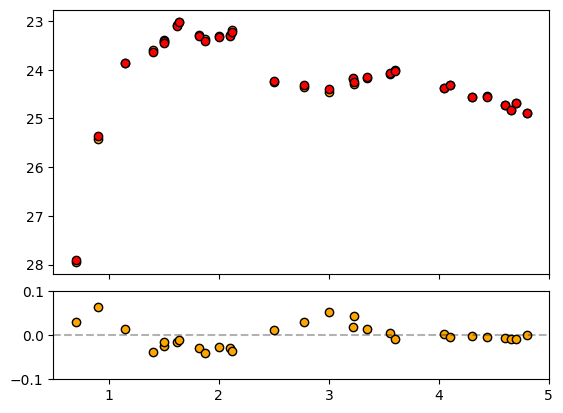

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.scatter(wv_all, interp_val, fc='orange', ec='black')
ax1.scatter(wv_all, interp_test, fc='red', ec='black')
ax1.invert_yaxis()

ax2.scatter(wv_all, np.array(interp_val)-np.array(interp_test), fc='orange', ec='black')
ax2.axhline(0.0, ls='--', color='black', alpha=0.3)
ax2.set_ylim(-0.1, 0.1)

fig.subplots_adjust(hspace=0.1)

In [14]:
def calculate_extinction(wvs, Av, Rv, bandpass):
    test = extinction_law(wvs.value, Av, Rv)
    flat = np.zeros(len(wvs))+spec['flam_0.01'][mask]*1e3

    test1 = synphot.SourceSpectrum(Empirical1D, points=wvs, lookup_table=flat)
    test2 = synphot.SourceSpectrum(Empirical1D, points=wvs, lookup_table=flat*test)

    kwargs = {'force': 'taper', 'binset': wvs}

    obs1 = synphot.Observation(test1, bandpass, **kwargs)
    obs2 = synphot.Observation(test2, bandpass, **kwargs)

    # This is extinction in bandpass
    print(obs1.effstim('abmag'), obs2.effstim('abmag'))
    a_lambda = obs2.effstim('abmag')-obs1.effstim('abmag')

    return(a_lambda)

In [15]:
wv = spec['lambda']
_, mask = np.unique(wv, return_index=True)
wv = wv[mask].to(u.Angstrom)

In [16]:
Av, Rv = 0.5, 6.0
el = extinction_law(wv.value, Av, Rv)
calculate_extinction(wv, Av, Rv, get_jwst_filters('NIRCAM,F150W')).value

-0.6048460372901288 mag(AB) -0.47973007823299546 mag(AB)


np.float64(0.1251159590571333)

In [17]:
with open(os.path.join('data', 'interpolate', 'rsg_sil_r2_ext.pkl'), 'rb') as f:
    models_ext = pickle.load(f)

In [18]:
tg, dtg, tug, lg, r, a = np.meshgrid(4500, 1200, 0.3, 1e5, 5.1, 0.6, indexing='ij', sparse=True)
models_ext['F150W']((tg, dtg, tug, lg, r, a)).flatten()

array([21.62543367])

In [19]:
interp_ext, interp_val = [], []
nrc_s = ['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F250M', 'F277W', 'F356W', 'F444W']
wv_s = [float(i.split('F')[1].split('W')[0].split('M')[0]) for i in nrc_s]

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]
for f_ in nrc_filts:
    interp_ext.append(models_ext[f_]((tg, dtg, tug, lg, r, a)).flatten())
    interp_val.append(models[f_]((tg, dtg, tug, lg)).flatten())

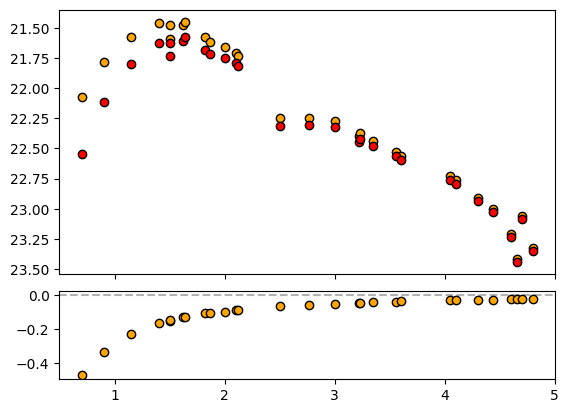

In [20]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.scatter(wv_all, interp_val, fc='orange', ec='black')
ax1.scatter(wv_all, interp_ext, fc='red', ec='black')
ax1.invert_yaxis()

ax2.scatter(wv_all, np.array(interp_val)-np.array(interp_ext), fc='orange', ec='black')
ax2.axhline(0.0, ls='--', color='black', alpha=0.3)
# ax2.set_ylim(-0.1, 0.1)

fig.subplots_adjust(hspace=0.1)

### likelihood

In [3]:
import pandas as pd

In [4]:
def lin(x, m, c): return m*x+c

cat = None
for fl in glob.glob('data/dolphot/ngc5643/proc/ngc5643_0_*.csv'):
    if cat is None:
        cat = pd.read_csv(fl)
    else:
        df_ = pd.read_csv(fl)
        cat = pd.concat([cat, df_])
cat.reset_index(inplace=True)

f1, f2 = 'F115W', 'F200W'
cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
rsg_mask = (m<25) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3.5))

rsgcat = cat[rsg_mask]
testcol = rsgcat.iloc[399]

In [5]:
with open(os.path.join('data', 'interpolate', 'rsg_sil_r2_ext.pkl'), 'rb') as f:
    models_ext = pickle.load(f)

In [6]:
params = np.meshgrid(3900, 800, 0.3, 1e5, 3.1, 0.2, indexing='ij', sparse=True)
gin = tuple(params)

In [7]:
mmask = ['mag' in i for i in rsgcat.columns]
flts = [i.replace('_mag','') for i in rsgcat.columns[mmask]]
magcols = [i+'_mag' for i in flts]
errcols = [i+'_err' for i in flts]

In [16]:
model_mag = np.array([models_ext[i](tuple(params)).flatten()[0] for i in flts])+0.484550065

In [21]:
phot = {'mag': testcol[magcols].values,
        'magerr': testcol[errcols].values,
        'inst_filt': np.array(flts),
        'index': f'ngc5643_{int(testcol['index'])}'}

In [22]:
fl_mask = np.array(['N' in i for i in phot['inst_filt']])
phot['mag'] = phot['mag'][~fl_mask]
phot['magerr'] = phot['magerr'][~fl_mask]
phot['inst_filt'] = phot['inst_filt'][~fl_mask]
model_mag = model_mag[~fl_mask]

In [23]:
limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
mag = phot['mag'][~limmask]
magerr = phot['magerr'][~limmask]
model_mag = model_mag[~limmask]

In [24]:
chi2 = 1.0
chi2 *= np.sum((mag-model_mag)**2/magerr**2)
chi2

np.float64(280110.7207361578)

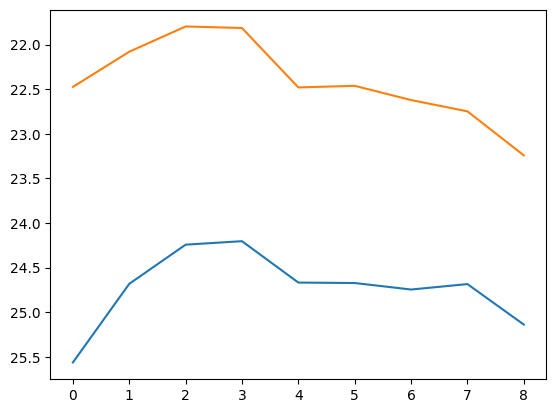

In [25]:
plt.plot(mag)
plt.plot(model_mag)
plt.gca().invert_yaxis()

In [230]:
%reload_ext autoreload
%autoreload 2

from mcmc import mcmc

In [253]:
keep_narrow = False
testcol = rsgcat.sample(1).iloc[0]
# testcol = rsgcat.loc[rsgcat['index'] == 15941]

phot = {'mag': testcol[magcols].values,
        'magerr': testcol[errcols].values,
        'inst_filt': np.array(flts),
        'index': f'ngc5643_{int(testcol['index'])}'}

if not keep_narrow:
        fl_mask = np.array(['N' in i for i in phot['inst_filt']])
        phot['mag'] = phot['mag'][~fl_mask]
        phot['magerr'] = phot['magerr'][~fl_mask]
        phot['inst_filt'] = phot['inst_filt'][~fl_mask]

limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
phot['mag'] = phot['mag'][~limmask]
phot['magerr'] = phot['magerr'][~limmask]
phot['inst_filt'] = phot['inst_filt'][~limmask]

In [254]:
mc_obj = mcmc(dm=30.57, dmerr=0.06)
mc_obj.verbose = True

In [255]:
fit_params = mc_obj.run_emcee(phot, nsteps=500, sigma=1.0)

Backend file: data/backends/ngc5643_36143_rsg.h5
Backend name: 23087170093606398818956


  0%|          | 0/500 [00:00<?, ?it/s]/Users/aswin/anaconda3/envs/synphot/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 500/500 [00:43<00:00, 11.41it/s]

Backend file: data/backends/ngc5643_36143_rsg.h5
Backend name: 23087170093606398818956
Current number of samples in backend: 50000
Minimum chi^2 is: 24.7404284



temperature       :     3478.246 + 301.7539999999999 - 188.2460000000001
dust_temp         :     1104.421 + 195.57899999999995 - 234.42100000000005
tau_V             :        0.664 +        0.632 -        0.625
luminosity        :     8193.378 + 1926.7419338913378 - 843.497933891339
Rv                :         4.05 +         1.04 -         0.92
Av                :        0.619 +        0.563 -        0.319


In [256]:
reader = mc_obj.load_backend(phot)
sample = np.array(reader.get_chain(flat=True))

Backend file: data/backends/ngc5643_36143_rsg.h5
Backend name: 23087170093606398818956


In [236]:
mc_obj.get_init_pos(mc_obj.get_guess('rsg', 'params'), 6, 1, sigma=0.1)

[array([3.19619161e+03, 7.23831641e+02, 2.25567715e-02, 1.60466436e+04,
        3.17034649e+00, 1.23792148e-01])]

In [237]:
mc_obj.get_guess('rsg', 'params') * np.random.normal(1.0,0.01,6)

array([3.25156773e+03, 7.92729404e+02, 2.00607454e-02, 1.60700360e+04,
       3.08970952e+00, 1.24185703e-01])

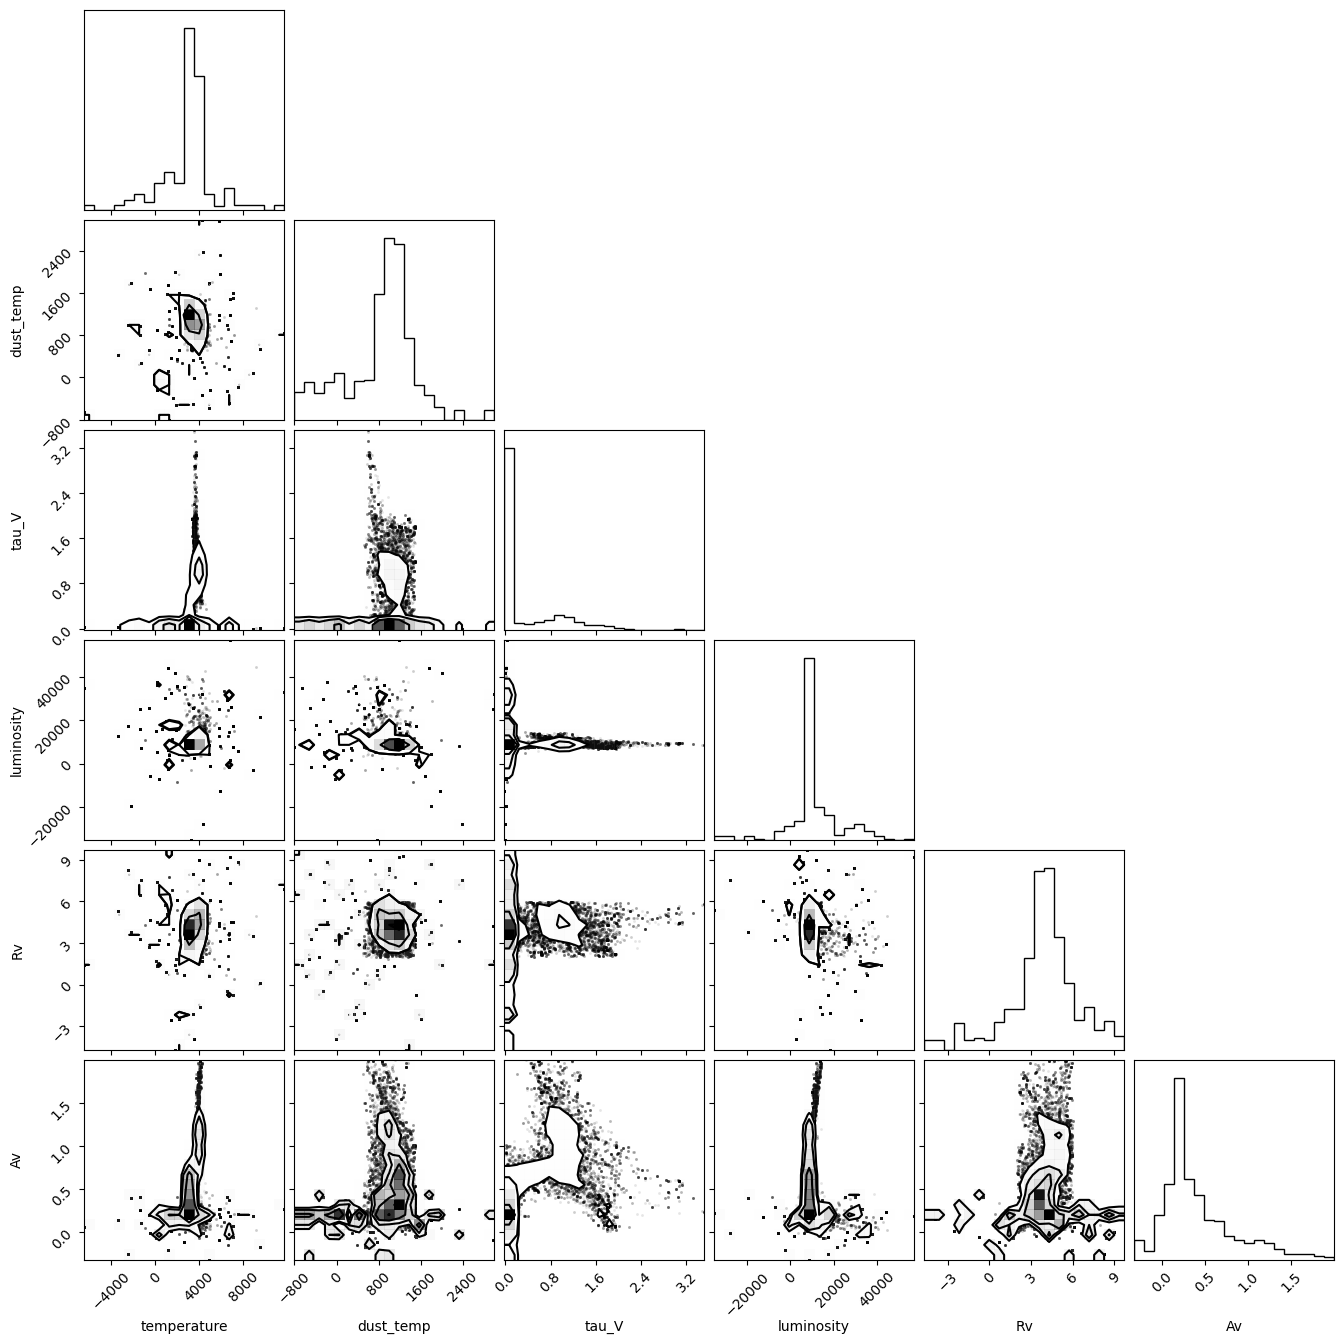

In [257]:
import corner

fig = corner.corner(
    sample, labels=mc_obj.model_fit_params[mc_obj.model_type],
);

In [211]:
test_params=mc_obj.get_init_pos(mc_obj.get_guess('rsg', 'params'), 6, 1, sigma=0.1)

In [212]:
mc_obj.check_bounds(test_params[0])

False

In [213]:
test_params[0]

array([3.43233786e+03, 8.14278640e+02, 2.01454558e-02, 1.48857472e+04,
       2.81528360e+00, 1.22712266e-01])

In [197]:
test_params

[array([3.06701315e+03, 8.18782447e+02, 2.08223159e-02, 1.78148180e+04,
        1.25286193e-01, 3.34063605e+00])]

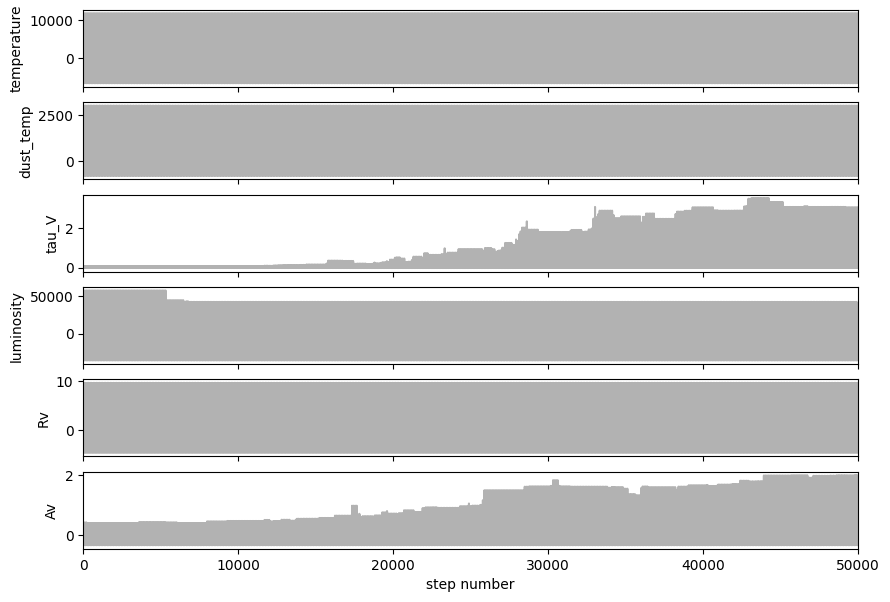

In [258]:
labels = mc_obj.model_fit_params[mc_obj.model_type]
fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(len(labels)):
    ax = axes[i]
    ax.plot(sample[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(sample))
    ax.set_ylabel(labels[i])
    # ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [259]:
params = np.meshgrid(*fit_params, indexing='ij', sparse=True)
model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm

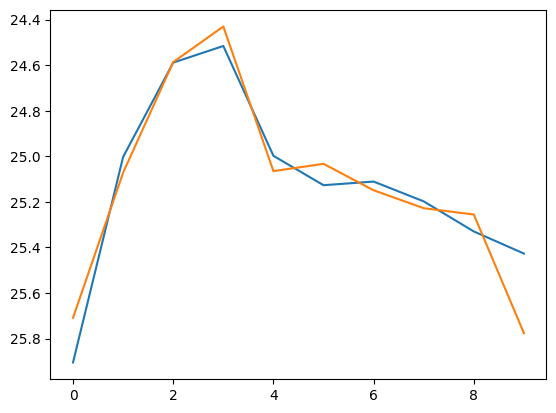

In [260]:
plt.plot(phot['mag'])
plt.plot(model_mag)
plt.gca().invert_yaxis()